# Detección de tono de piel para corrección de señal PPG
## Índice de Tipología Individual (ITA)

Usamos el ITA (Individual Typology Angle) porque nos da un valor numérico
continuo — ideal para correlacionar con el margen de error del PPG más adelante.

La fórmula es:
ITA = arctan((L* - 50) / b*) × (180 / π)

Donde L* y b* son componentes del espacio de color CIELab:
- L* = luminosidad (0=negro, 100=blanco)
- b* = eje amarillo-azul (positivo=amarillo, negativo=azul)

Clasificación ITA:
- ITA > 55°  → Muy clara
- 41° a 55°  → Clara  
- 28° a 41°  → Intermedia
- 10° a 28°  → Morena
- -30° a 10° → Oscura
- ITA < -30° → Muy oscura

## Librerías necesarias

Usamos OpenCV para leer y procesar la imagen, y scikit-image
para convertir entre espacios de color. La conversión a CIELab
es necesaria porque el ITA está definido en ese espacio.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage import color

## Cargar la imagen

Cargaremos la foto de la zona de medición.
Tomaremos la foto con buena iluminación natural.

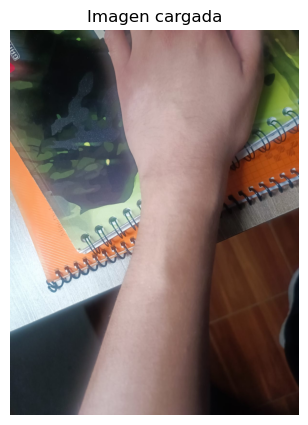

Resolución: 1200 x 1600 px


In [2]:
imagen_bgr = cv2.imread('imagen/imagen1.jpeg')

# OpenCV carga en BGR, convertimos a RGB para trabajar bien
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(imagen_rgb)
plt.title('Imagen cargada')
plt.axis('off')
plt.show()

print(f"Resolución: {imagen_rgb.shape[1]} x {imagen_rgb.shape[0]} px")

## Selección de la región de interés (ROI)

No podemos calcular el ITA de toda la imagen — si hay fondo, ropa
o sombras, van a contaminar el resultado. Necesitamos recortar
solo la zona de piel donde va el sensor.

Definimos manualmente las coordenadas del recorte.

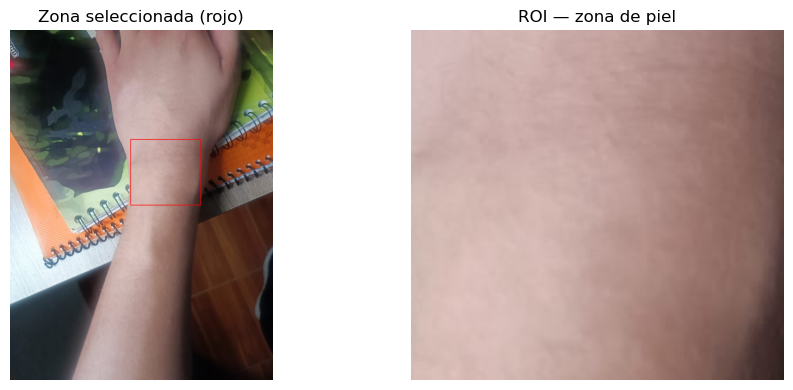

In [ ]:
# coordenadas del recorte
x      = 550   # píxel de inicio horizontal
y      = 500   # píxel de inicio vertical
ancho  = 320   # cuántos píxeles hacia la derecha
alto   = 300   # cuántos píxeles hacia abajo

roi = imagen_rgb[y:y+alto, x:x+ancho]

imagen_marcada = imagen_rgb.copy()
cv2.rectangle(imagen_marcada, (x, y), (x+ancho, y+alto), (255, 0, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(imagen_marcada)
axes[0].set_title('Zona seleccionada (rojo)')
axes[0].axis('off')

axes[1].imshow(roi)
axes[1].set_title('ROI — zona de piel')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Conversión a CIELab

RGB es el espacio de color de las pantallas pero no está diseñado
para medir percepción humana del color. CIELab sí — fue creado
para que distancias iguales en el espacio correspondan a diferencias
iguales percibidas por el ojo humano.

La conversión requiere que los valores RGB estén normalizados entre 0 y 1.

In [11]:
# normalizar a 0-1 antes de convertir
roi_norm = roi.astype(np.float64) / 255.0

# convertir a CIELab
roi_lab = color.rgb2lab(roi_norm)

# separar canales
L = roi_lab[:, :, 0]   # luminosidad
a = roi_lab[:, :, 1]   # eje verde-rojo
b = roi_lab[:, :, 2]   # eje azul-amarillo

print(f"L* promedio: {L.mean():.2f}  (0=negro, 100=blanco)")
print(f"a* promedio: {a.mean():.2f}  (negativo=verde, positivo=rojo)")
print(f"b* promedio: {b.mean():.2f}  (negativo=azul, positivo=amarillo)")

L* promedio: 64.16  (0=negro, 100=blanco)
a* promedio: 10.85  (negativo=verde, positivo=rojo)
b* promedio: 7.43  (negativo=azul, positivo=amarillo)


## Cálculo del ITA

Con L* y b* ya podemos calcular el ITA.
Usamos los valores promedio de toda la ROI para obtener
un valor representativo de la zona de medición.

In [12]:
def calcular_ita(L_mean, b_mean):
    ita = np.arctan((L_mean - 50) / b_mean) * (180 / np.pi)
    return ita

def clasificar_ita(ita):
    if ita > 55:
        return "Muy clara"
    elif ita > 41:
        return "Clara"
    elif ita > 28:
        return "Intermedia"
    elif ita > 10:
        return "Morena"
    elif ita > -30:
        return "Oscura"
    else:
        return "Muy oscura"

L_mean = L.mean()
b_mean = b.mean()

ita = calcular_ita(L_mean, b_mean)
categoria = clasificar_ita(ita)

print(f"ITA calculado: {ita:.2f}°")
print(f"Categoría:     {categoria}")

ITA calculado: 62.31°
Categoría:     Muy clara


## Visualización del resultado

Graficamos la escala completa de ITA y marcamos dónde
cae el valor calculado. Esto nos va a servir más adelante
para comparar varias muestras de diferentes personas.

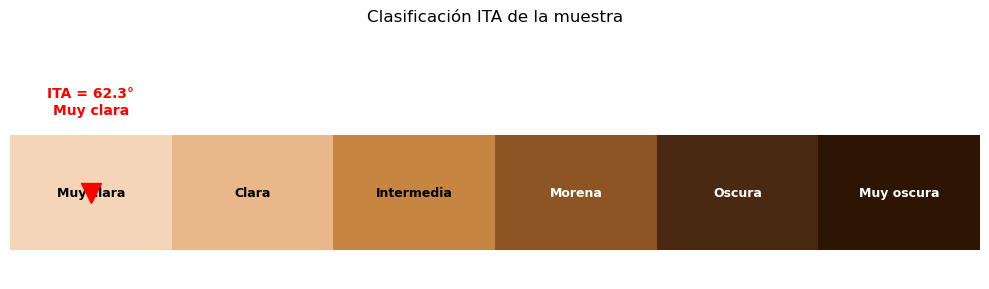

In [13]:
categorias  = ["Muy clara", "Clara", "Intermedia", "Morena", "Oscura", "Muy oscura"]
limites_ita = [55, 41, 28, 10, -30, -60]
colores_piel = ['#f5d5b8', '#e8b88a', '#c68642', '#8d5524', '#4a2912', '#2c1503']

fig, ax = plt.subplots(figsize=(10, 3))

for i, (cat, col) in enumerate(zip(categorias, colores_piel)):
    ax.barh(0, 1, left=i, color=col, height=0.8)
    ax.text(i + 0.5, 0, cat, ha='center', va='center',
            fontsize=9, color='white' if i > 2 else 'black', fontweight='bold')

# marcar el valor calculado
posicion = categorias.index(categoria)
ax.plot(posicion + 0.5, 0, 'v', color='red', markersize=15, zorder=5)
ax.text(posicion + 0.5, 0.55, f'ITA = {ita:.1f}°\n{categoria}',
        ha='center', fontsize=10, color='red', fontweight='bold')

ax.set_xlim(0, 6)
ax.set_ylim(-0.6, 1)
ax.axis('off')
ax.set_title('Clasificación ITA de la muestra', fontsize=12, pad=20)

plt.tight_layout()
plt.show()

## Registro de la muestra

Guardamos los valores en un diccionario para después
correlacionarlos con las lecturas del PPG y el baumanómetro manual.
Cada persona que midamos va a tener su propio registro.

In [14]:
muestra = {
    'L_mean':    round(L_mean, 2),
    'b_mean':    round(b_mean, 2),
    'ITA':       round(ita, 2),
    'categoria': categoria,
    'SBP_manual':  None,   # sistólica baumanómetro manual (mmHg)
    'DBP_manual':  None,   # diastólica baumanómetro manual (mmHg)
    'SBP_ppg':     None,   # sistólica estimada por PPG (mmHg)
    'DBP_ppg':     None,   # diastólica estimada por PPG (mmHg)
}

print("Registro de la muestra:")
for clave, valor in muestra.items():
    print(f"  {clave}: {valor}")

Registro de la muestra:
  L_mean: 64.16
  b_mean: 7.43
  ITA: 62.31
  categoria: Muy clara
  SBP_manual: None
  DBP_manual: None
  SBP_ppg: None
  DBP_ppg: None
